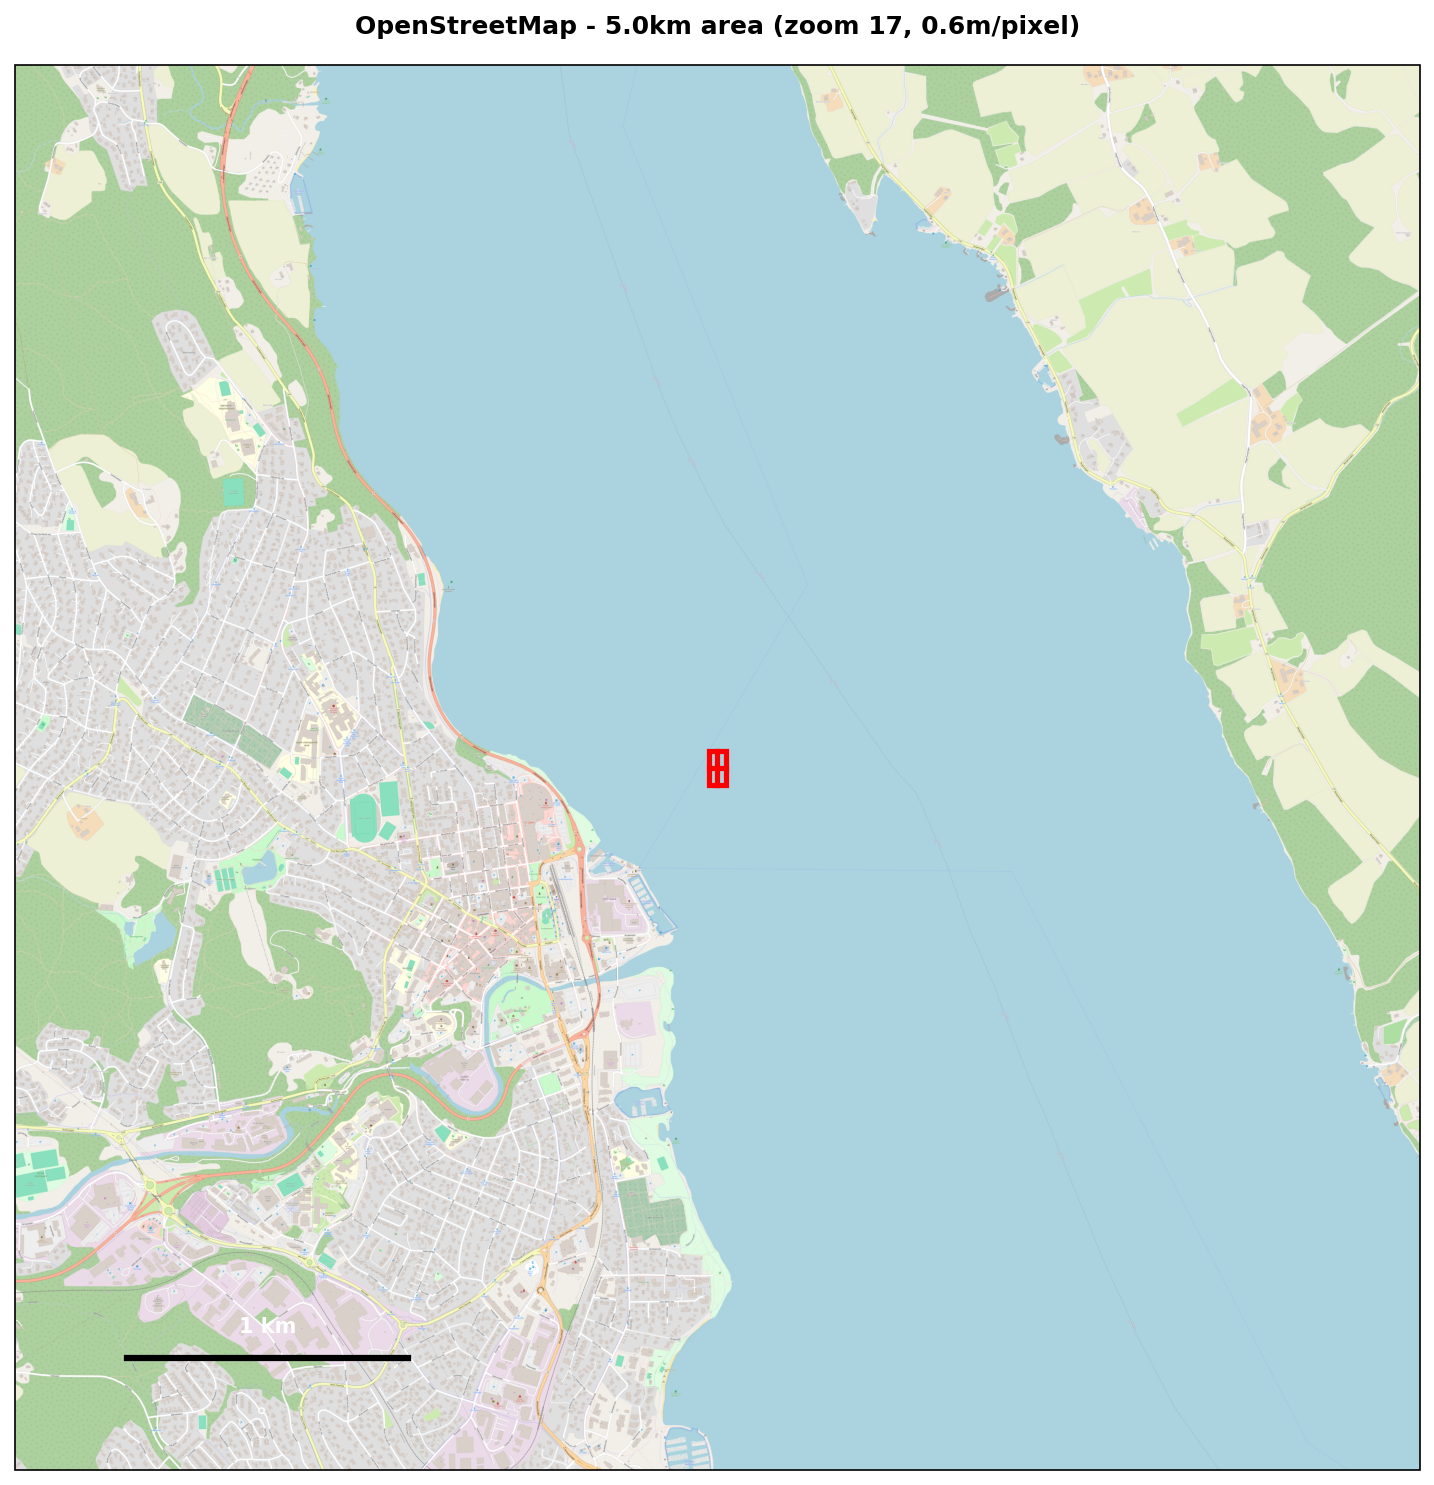

✓ Map created successfully!
  Center: 60.801146°N, 10.705125°E
  Area: 5.0km × 5.0km
  Tile zoom: 17
  Resolution: 0.58 meters/pixel


In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import numpy as np
import sys
from pathlib import Path

# Import config
mjosa_code_root = Path.cwd().parent
sys.path.insert(0, str(mjosa_code_root))
from utils.common import config


def create_osm_map(
    lat_center,
    lon_center,
    extent_km=5,
    tile_zoom=17,
    fig_width=8,
    fig_height=8,
    dpi=300,
    show_gridlines=True,
    gridline_color="white",
    scale_bar_km=1,
    show_origin_cross=True,
    show_origin_square=True,
    marker_size=0.006,
    marker_color="red",
    marker_linewidth=2.5,
    title=None,
    save_file=None,
):
    """
    Create an OpenStreetMap with full control over area and detail.

    Parameters:
    -----------
    lat_center, lon_center : float
        Center point of the map (decimal degrees)
    extent_km : float
        Half-width of the map in kilometers (total area = 2×extent_km squared)
        Examples: 5 = 10km×10km, 1 = 2km×2km, 0.5 = 1km×1km
    tile_zoom : int
        OSM tile zoom level (14-19 recommended)
        14 = low detail/fast, 17 = high detail, 19 = very high detail/slow
    fig_width, fig_height : float
        Figure size in inches
    dpi : int
        Resolution (300 = publication quality)
    show_gridlines : bool
        Whether to show gridlines with lat/lon labels (True/False)
    gridline_color : str
        Color for gridlines ('white', 'black', 'red', 'yellow', etc.)
    scale_bar_km : float
        Length of scale bar in kilometers
    show_origin_cross : bool
        Whether to show cross (+) at origin (True/False)
    show_origin_square : bool
        Whether to show square around origin (True/False)
    marker_size : float
        Size of marker relative to map extent (0.006 = default)
    marker_color : str
        Color of marker cross and square ('red', 'blue', 'black', etc.)
    marker_linewidth : float
        Line width for marker cross and square (2.5 = default)
    title : str or None
        Map title (None = auto-generate)
    save_file : str or None
        Filename to save (None = don't save, just display)

    Returns:
    --------
    fig, ax : matplotlib figure and axis objects
    """

    # Calculate extent
    km_per_deg_lat = 111.0
    km_per_deg_lon = 111.0 * np.cos(np.radians(lat_center))

    lat_span = extent_km / km_per_deg_lat
    lon_span = extent_km / km_per_deg_lon

    extent = [
        lon_center - lon_span,  # left
        lon_center + lon_span,  # right
        lat_center - lat_span,  # bottom
        lat_center + lat_span,  # top
    ]

    # Create figure
    fig = plt.figure(figsize=(fig_width, fig_height), dpi=dpi)
    tile_source = cimgt.OSM()
    ax = plt.axes(projection=tile_source.crs)
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    # Add map tiles
    print(
        f"Downloading tiles (zoom {tile_zoom}, {extent_km*2}km × {extent_km*2}km area)..."
    )
    ax.add_image(tile_source, tile_zoom)

    # Add gridlines (optional)
    if show_gridlines:
        gl = ax.gridlines(
            draw_labels=True,
            linewidth=0.8,
            color=gridline_color,
            alpha=0.8,
            linestyle="--",
        )
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 10, "color": gridline_color, "weight": "bold"}
        gl.ylabel_style = {"size": 10, "color": gridline_color, "weight": "bold"}
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER

    # Scale bar
    scale_lon = scale_bar_km / km_per_deg_lon
    scale_x = extent[0] + 0.08 * (extent[1] - extent[0])
    scale_y = extent[2] + 0.08 * (extent[3] - extent[2])

    # Scale bar (just the black line, no white border)
    ax.plot(
        [scale_x, scale_x + scale_lon],
        [scale_y, scale_y],
        "k-",
        linewidth=3,
        transform=ccrs.PlateCarree(),
        zorder=11,
    )

    # Scale text (no background)
    ax.text(
        scale_x + scale_lon / 2,
        scale_y + 0.015 * (extent[3] - extent[2]),
        f"{scale_bar_km} km",
        ha="center",
        va="bottom",
        fontsize=10,
        weight="bold",
        color="black",
        transform=ccrs.PlateCarree(),
        zorder=12,
    )

    # Mark origin point with cross and/or square
    # The cross arms extend half the marker size in each direction
    marker_half_size = marker_size * (extent[1] - extent[0])  # Half-width of cross arms

    if show_origin_cross:
        # Vertical line of cross (|)
        ax.plot(
            [lon_center, lon_center],
            [lat_center - marker_half_size, lat_center + marker_half_size],
            color=marker_color,
            linewidth=marker_linewidth,
            transform=ccrs.PlateCarree(),
            zorder=15,
        )

        # Horizontal line of cross (-)
        ax.plot(
            [lon_center - marker_half_size, lon_center + marker_half_size],
            [lat_center, lat_center],
            color=marker_color,
            linewidth=marker_linewidth,
            transform=ccrs.PlateCarree(),
            zorder=15,
        )

    if show_origin_square:
        # Square with corners at the ends of cross lines
        square = plt.Rectangle(
            (lon_center - marker_half_size, lat_center - marker_half_size),
            2 * marker_half_size,
            2 * marker_half_size,
            fill=False,
            edgecolor=marker_color,
            linewidth=marker_linewidth,
            transform=ccrs.PlateCarree(),
            zorder=14,
        )
        ax.add_patch(square)

    # Title
    if title is None:
        m_per_pixel = 156543.03392 * np.cos(lat_center * np.pi / 180) / (2**tile_zoom)
        title = f"OpenStreetMap - {extent_km*2}km area (zoom {tile_zoom}, {m_per_pixel:.1f}m/pixel)"

    plt.title(title, fontsize=12, pad=15, weight="bold")
    plt.tight_layout()

    # Save if requested
    if save_file:
        plt.savefig(save_file, dpi=dpi, bbox_inches="tight", facecolor="white")
        print(f"✅ Saved: {save_file}")

    plt.show()

    print(f"✓ Map created successfully!")
    print(f"  Center: {lat_center}°N, {lon_center}°E")
    print(f"  Area: {extent_km*2}km × {extent_km*2}km")
    print(f"  Tile zoom: {tile_zoom}")
    print(f"  Resolution: {m_per_pixel:.2f} meters/pixel")

    return fig, ax


# ============================================================================
# CREATE YOUR MAP - Adjust parameters directly in the function call
# ============================================================================

✅ Saved: e:\mjosa_complete\gref4hsi\mjosa_code\images_for_publication\study_site_map.pdf


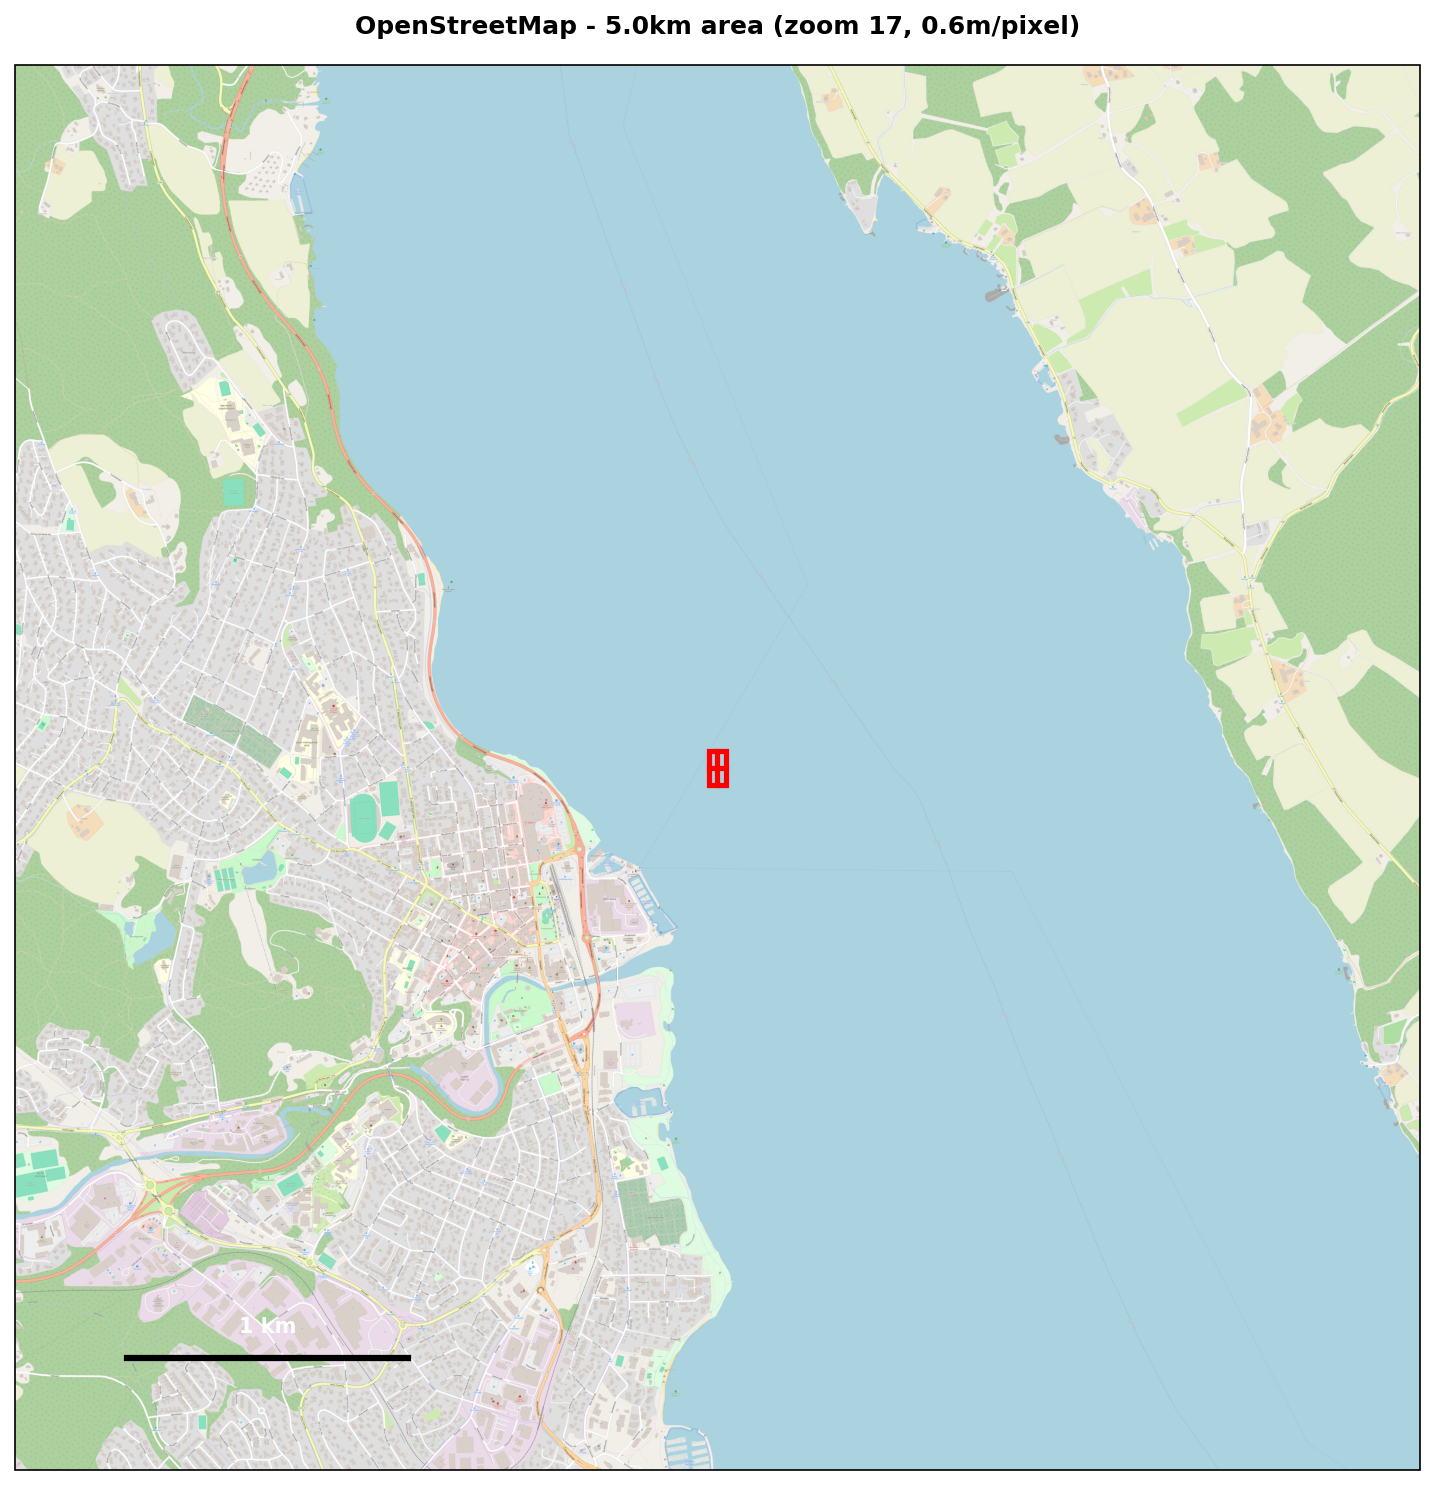

✓ Map created successfully!
  Center: 60.801146°N, 10.705125°E
  Area: 5.0km × 5.0km
  Tile zoom: 17
  Resolution: 0.58 meters/pixel

📁 Saved to: e:\mjosa_complete\gref4hsi\mjosa_code\images_for_publication\study_site_map.pdf


In [ ]:
# Save to images_for_publication folder
from pathlib import Path

output_dir = Path.cwd().parent / "images_for_publication"
output_dir.mkdir(exist_ok=True)
output_file = output_dir / "study_site_map.pdf"


fig, ax = create_osm_map(
    lat_center=config.LAT0,  # Center latitude
    lon_center=config.LON0,  # Center longitude
    extent_km=2.5,  # Half-width in km (2.5 = 5km×5km map)
    tile_zoom=17,  # 14=fast, 15=good, 17=high, 19=max
    fig_width=10,  # Figure width in inches
    fig_height=10,  # Figure height in inches
    dpi=150,  # Resolution (300=publication, 150=screen)
    show_gridlines=False,  # True/False to show/hide gridlines
    scale_bar_km=1,  # Scale bar length in km
    show_origin_cross=True,  # True/False to show/hide cross
    show_origin_square=True,  # True/False to show/hide square
    marker_size=0.006,  # Marker size (0.006=default, 0.01=larger)
    marker_color="red",  # Marker color ('red', 'blue', 'black', etc.)
    marker_linewidth=2.5,  # Marker line thickness (2.5=default)
    title=None,  # None=auto, or "My Custom Title"
    save_file=None,
    # save_file=str(output_file),
)

print(f"\n📁 Saved to: {output_file}")

In [ ]:
fig, ax = create_osm_map(
    lat_center=config.LAT0,  # Center latitude
    lon_center=config.LON0,  # Center longitude
    extent_km=1000,  # Half-width in km (2.5 = 5km×5km map)
    tile_zoom=17,  # 14=fast, 15=good, 17=high, 19=max
    fig_width=10,  # Figure width in inches
    fig_height=10,  # Figure height in inches
    dpi=150,  # Resolution (300=publication, 150=screen)
    show_gridlines=False,  # True/False to show/hide gridlines
    scale_bar_km=1,  # Scale bar length in km
    show_origin_cross=True,  # True/False to show/hide cross
    show_origin_square=True,  # True/False to show/hide square
    marker_size=0.006,  # Marker size (0.006=default, 0.01=larger)
    marker_color="red",  # Marker color ('red', 'blue', 'black', etc.)
    marker_linewidth=2.5,  # Marker line thickness (2.5=default)
    title=None,  # None=auto, or "My Custom Title"
    save_file=None,
    # save_file=str(output_file),
)